# 📊 Etapa 3 — Avaliação Comparativa dos Quatro Modelos Fine-Tuned

Este notebook avalia e compara os **quatro modelos** treinados na Etapa 2
usando o pipeline de métricas de NLP exigido pelo trabalho.

| ID | Modelo | Tipo | Especialização |
|---|---|---|---|
| **C1** | `gpt2-small-portuguese` | Causal LM | PT-BR especializado |
| **C2** | `bloom-560m` | Causal LM | Multilingual (46 línguas) |
| **S1** | `ptt5-base-portuguese-vocab` | Seq2Seq | PT-BR especializado |
| **S2** | `mt5-small` | Seq2Seq | Multilingual (101 línguas) |

## 🗺️ Métricas Avaliadas

| Métrica | Foco | Intervalo |
|---|---|---|
| **Perplexidade (PPL)** | Capacidade preditiva sobre o texto de referência | Menor = melhor |
| **BLEU** | Precisão de n-gramas vs. referência | 0–100 (maior = melhor) |
| **ROUGE** | Recall de sobreposição de conteúdo | 0–1 (maior = melhor) |
| **Fidelidade (Faithfulness)** | Resposta factualmente consistente com a instrução | 0–1 (maior = melhor) |
| **Relevância (Answer Relevance)** | Resposta responde à pergunta feita | 0–1 (maior = melhor) |
| **Aderência ao Plano (Plan Adherence)** | Resposta segue estrutura da referência | 0–1 (maior = melhor) |


## 📦 1. Instalação de Dependências


In [ ]:
!pip install -q transformers peft torch sacrebleu rouge-score nltk pandas \
             matplotlib seaborn tqdm sentencepiece
!pip uninstall -y torchao 2>/dev/null || true

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

print('✅ Dependências instaladas!')


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.1 MB/s eta 0:00:00
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
✅ Dependências instaladas!


## 🔗 2. Montar o Google Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 📥 3. Importações

Importamos classes para **dois tipos de modelo**:
- `AutoModelForCausalLM` — Causal 1 (GPT-2 PT) e Causal 2 (BLOOM)
- `AutoModelForSeq2SeqLM` — Seq2Seq 1 (ptt5) e Seq2Seq 2 (mT5)


In [ ]:
import json, math, re, warnings
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from tqdm import tqdm

from transformers import (
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
)
from peft import PeftModel
from sacrebleu.metrics import BLEU
from rouge_score import rouge_scorer
from nltk.tokenize import word_tokenize

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Importações concluídas!')
print(f'   PyTorch  : {torch.__version__}')
print(f'   Device   : {DEVICE}')


✅ Importações concluídas!
   PyTorch  : 2.11.0+cpu
   Device   : cpu


## 📂 4. Carregar o Dataset

O dataset usa o formato do trabalho: campos `Instruction` e `Output` (capitalizados).
Usamos o **conjunto de teste** (seed=42, 20% dos dados) — o mesmo split
usado em todos os modelos durante o treinamento, garantindo comparação justa.


In [ ]:
DATASET_PATH = '/content/drive/MyDrive/dataset_gerado_v3 (1).jsonl'

all_samples = []
with open(DATASET_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            all_samples.append(json.loads(line))

# Reproduz o mesmo split de teste usado no treinamento (seed=42, test_size=0.2)
import random
random.seed(42)
indices = list(range(len(all_samples)))
random.shuffle(indices)
test_size = int(len(all_samples) * 0.2)
test_indices = indices[:test_size]
samples = [all_samples[i] for i in sorted(test_indices)]

print(f'✅ Dataset carregado: {len(all_samples)} total, {len(samples)} no conjunto de teste')
print(f'\nExemplos do conjunto de teste:')
for s in samples[:2]:
    print(f'  Instruction: {s["Instruction"][:70]}')
    print(f'  Output:      {s["Output"][:70]}')
    print()

✅ Dataset carregado: 152 total, 30 no conjunto de teste

Exemplos do conjunto de teste:
  Instruction: Qual é a principal função do manual de instruções fornecido pela March
  Output:      O manual de instruções serve para orientar sobre como usar efetivament

  Instruction: Como o usuário pode obter assistência técnica sobre a operação do equi
  Output:      Para obter assistência técnica, você pode entrar em contato diretament



## 🤖 5. Carregar os Quatro Modelos Fine-Tuned

Definimos funções separadas para carregar modelos **Causais** e **Seq2Seq**,
pois usam classes diferentes do HuggingFace.

Cada modelo é carregado como `PeftModel` sobre seu modelo base original.


In [ ]:
def load_causal_model(base_model_name, lora_path):
    """Carrega modelo Causal LM com adaptadores LoRA."""
    print(f'  ⏳ Base: {base_model_name}')
    tokenizer = AutoTokenizer.from_pretrained(lora_path)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    base = AutoModelForCausalLM.from_pretrained(
        base_model_name, torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
    )
    model = PeftModel.from_pretrained(base, lora_path)
    model.eval().to(DEVICE)
    return model, tokenizer


def load_seq2seq_model(base_model_name, lora_path):
    """Carrega modelo Seq2Seq com adaptadores LoRA."""
    print(f'  ⏳ Base: {base_model_name}')
    tokenizer = AutoTokenizer.from_pretrained(lora_path)
    base = AutoModelForSeq2SeqLM.from_pretrained(
        base_model_name, torch_dtype=torch.float32
    )
    model = PeftModel.from_pretrained(base, lora_path)
    model.eval().to(DEVICE)
    return model, tokenizer


# ── Caminhos dos modelos salvos ───────────────────────────────────────────
CAUSAL_1_BASE = 'pierreguillou/gpt2-small-portuguese'
CAUSAL_1_PATH = '/content/drive/MyDrive/lora_causal_model_1'

CAUSAL_2_BASE = 'bigscience/bloom-560m'
CAUSAL_2_PATH = '/content/drive/MyDrive/lora_causal_model_2'

SEQ2SEQ_1_BASE = 'unicamp-dl/ptt5-base-portuguese-vocab'
SEQ2SEQ_1_PATH = '/content/drive/MyDrive/lora_seq2seq_model_1'

SEQ2SEQ_2_BASE = 'google/mt5-small'
SEQ2SEQ_2_PATH = '/content/drive/MyDrive/lora_seq2seq_model_2'
# ─────────────────────────────────────────────────────────────────────────

print('Carregando Causal 1 (gpt2-small-portuguese)...')
model_c1, tok_c1 = load_causal_model(CAUSAL_1_BASE, CAUSAL_1_PATH)

print('Carregando Causal 2 (bloom-560m)...')
model_c2, tok_c2 = load_causal_model(CAUSAL_2_BASE, CAUSAL_2_PATH)

print('Carregando Seq2Seq 1 (ptt5-base)...')
model_s1, tok_s1 = load_seq2seq_model(SEQ2SEQ_1_BASE, SEQ2SEQ_1_PATH)

print('Carregando Seq2Seq 2 (mt5-small)...')
model_s2, tok_s2 = load_seq2seq_model(SEQ2SEQ_2_BASE, SEQ2SEQ_2_PATH)

MODELS = {
    'C1-GPT2-PT' : (model_c1, tok_c1, 'causal'),
    'C2-BLOOM'   : (model_c2, tok_c2, 'causal'),
    'S1-ptt5'    : (model_s1, tok_s1, 'seq2seq'),
    'S2-mT5'     : (model_s2, tok_s2, 'seq2seq'),
}

print(f'\n✅ {len(MODELS)} modelos carregados.')


Carregando Causal 1 (gpt2-small-portuguese)...
  ⏳ Base: pierreguillou/gpt2-small-portuguese


config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/510M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]


✅ 4 modelos carregados.


## ✍️ 6. Funções de Geração de Respostas

Como os modelos causais e Seq2Seq têm arquiteturas diferentes,
precisamos de funções de geração distintas:

- **Causal**: recebe `Instruction: ...\nOutput:` e gera continuação;
  extrai apenas o trecho após `Output:`.
- **Seq2Seq**: recebe apenas `Instruction: ...` no encoder;
  o decoder gera a resposta diretamente, sem necessidade de extração.


In [ ]:
def generate_causal(model, tokenizer, instruction, max_new_tokens=80):
    """Geração para modelos Causais (GPT-2 PT, BLOOM)."""
    prompt = f'Instruction: {instruction}\nOutput:'
    inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=256).to(DEVICE)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=3,
            early_stopping=True,
            pad_token_id=tokenizer.pad_token_id,
        )
    full = tokenizer.decode(out[0], skip_special_tokens=True)
    return full.split('Output:')[-1].strip()


def generate_seq2seq(model, tokenizer, instruction, max_new_tokens=80):
    """Geração para modelos Seq2Seq (ptt5, mT5)."""
    input_text = f'Instruction: {instruction}'
    inputs = tokenizer(input_text, return_tensors='pt',
                       truncation=True, max_length=128).to(DEVICE)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3,
        )
    return tokenizer.decode(out[0], skip_special_tokens=True).strip()


def generate(model, tokenizer, model_type, instruction):
    """Dispatch para o tipo correto de modelo."""
    if model_type == 'causal':
        return generate_causal(model, tokenizer, instruction)
    return generate_seq2seq(model, tokenizer, instruction)


# Teste rápido com a primeira amostra do conjunto de teste
test_instr = samples[0]['Instruction']
print(f'Instrução de teste: {test_instr}\n')
for name, (m, t, mtype) in MODELS.items():
    resp = generate(m, t, mtype, test_instr)
    print(f'  [{name}]: {resp[:100]}')
print(f'\n  [Referência]: {samples[0]["Output"]}')


Instrução de teste: Qual é a principal função do manual de instruções fornecido pela Marchesan S.A.?

  [C1-GPT2-PT]: A principal função do manual de instruções fornecido pela Marchesan S.A. é fornecer instruções espec
  [C2-BLOOM]: O manual de instruções fornecido pela Marchesan S.A. é
  [S1-ptt5]: O manual de instruções é fornecido pela Marchesan S.A..
  [S2-mT5]: <extra_id_0>.

  [Referência]: O manual de instruções serve para orientar sobre como usar efetivamente o equipamento, incluindo suas funções, procedimentos de operação e manutenção, além de garantir uma vida útil e confiabilidade máxima.


## ⚙️ 7. Gerar Respostas para Todos os Modelos

Geramos as respostas de todos os 4 modelos para todo o conjunto de teste.
Esse passo pode levar alguns minutos — as respostas são salvas em memória
e reutilizadas em todas as métricas seguintes.


In [ ]:
print('⏳ Gerando respostas para todos os modelos...')

all_generated = {}   # {model_name: [resp1, resp2, ...]}
references    = [s['Output'] for s in samples]

for name, (m, t, mtype) in MODELS.items():
    print(f'  → {name}')
    resps = []
    for s in tqdm(samples, desc=name, leave=False):
        resps.append(generate(m, t, mtype, s['Instruction']))
    all_generated[name] = resps

print('\n✅ Geração concluída!')
print(f'   Amostras avaliadas por modelo: {len(references)}')


⏳ Gerando respostas para todos os modelos...
  → C1-GPT2-PT


  → C2-BLOOM


  → S1-ptt5


  → S2-mT5



✅ Geração concluída!
   Amostras avaliadas por modelo: 30


## 📏 8. Métrica 1 — Perplexidade (PPL)

A Perplexidade mede o quão bem o modelo prevê o texto de referência.

$$\text{PPL} = \exp\left(-\frac{1}{N}\sum_{i=1}^{N} \log P(w_i | \text{contexto})\right)$$

**PPL baixa** → modelo prevê bem o texto de referência → melhor desempenho.

### Cálculo por tipo de modelo
- **Causal**: concatena `Instruction: ...\nOutput: <referência>` e calcula
  a loss apenas sobre os tokens do Output (mascarando a instrução com `-100`).
- **Seq2Seq**: passa a instrução ao encoder e a referência como `labels` ao decoder;
  a loss já é calculada apenas sobre o decoder por design da arquitetura.


In [ ]:
def ppl_causal(model, tokenizer, instruction, reference):
    """PPL para modelos causais — loss sobre tokens da resposta."""
    prompt    = f'Instruction: {instruction}\nOutput:'
    full_text = prompt + ' ' + reference

    enc_full   = tokenizer(full_text,  return_tensors='pt', truncation=True, max_length=256).to(DEVICE)
    enc_prompt = tokenizer(prompt,     return_tensors='pt', truncation=True, max_length=256)
    prompt_len = enc_prompt['input_ids'].shape[1]

    labels = enc_full['input_ids'].clone()
    labels[0, :prompt_len] = -100   # mascara a instrução

    with torch.no_grad():
        loss = model(input_ids=enc_full['input_ids'],
                     attention_mask=enc_full['attention_mask'],
                     labels=labels).loss
    return math.exp(loss.item())


def ppl_seq2seq(model, tokenizer, instruction, reference):
    """PPL para modelos Seq2Seq — loss sobre os labels do decoder."""
    enc = tokenizer(
        f'Instruction: {instruction}',
        return_tensors='pt', truncation=True, max_length=128
    ).to(DEVICE)
    lab = tokenizer(
        text_target=reference,
        return_tensors='pt', truncation=True, max_length=128
    ).to(DEVICE)

    with torch.no_grad():
        loss = model(
            input_ids=enc['input_ids'],
            attention_mask=enc['attention_mask'],
            labels=lab['input_ids']
        ).loss
    return math.exp(loss.item())


print('⏳ Calculando PPL...')
ppl_results = {}
for name, (m, t, mtype) in MODELS.items():
    scores = []
    for s in tqdm(samples, desc=name, leave=False):
        fn  = ppl_causal if mtype == 'causal' else ppl_seq2seq
        scores.append(fn(m, t, s['Instruction'], s['Output']))
    ppl_results[name] = scores
    print(f'  {name:<14} PPL média = {np.mean(scores):.2f}')

print('\n✅ PPL calculada!')


⏳ Calculando PPL...


C1-GPT2-PT:   0%|          | 0/30 [00:00<?, ?it/s][transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  C1-GPT2-PT     PPL média = 25.27


  C2-BLOOM       PPL média = 27.79


  S1-ptt5        PPL média = 26.99


  S2-mT5         PPL média = 2501028249204119615002489858818048.00

✅ PPL calculada!


## 🔵 9. Métrica 2 — BLEU

O **BLEU** mede a **precisão de n-gramas** entre o texto gerado e a referência.
Foca em precisão léxica — não captura paráfrases ou sinônimos.

**Limitações para português técnico**: respostas curtas e específicas como
*'Deve-se utilizar caminhão, carreta ou prancha'* dependem muito da escolha
exata de palavras — BLEU pode penalizar excessivamente paráfrases válidas.


In [ ]:
def compute_bleu(hypotheses, refs):
    bleu = BLEU(effective_order=True)
    result = bleu.corpus_score(hypotheses, [refs])
    bleu_s = BLEU(effective_order=True)
    per_sample = [bleu_s.sentence_score(h, [r]).score
                  for h, r in zip(hypotheses, refs)]
    return {
        'corpus'  : result.score,
        '1-gram'  : result.precisions[0],
        '2-gram'  : result.precisions[1],
        '3-gram'  : result.precisions[2],
        '4-gram'  : result.precisions[3],
        'bp'      : result.bp,
        'per_sample': per_sample,
    }


print('⏳ Calculando BLEU...')
bleu_results = {}
for name in MODELS:
    bleu_results[name] = compute_bleu(all_generated[name], references)
    print(f'  {name:<14} BLEU corpus = {bleu_results[name]["corpus"]:.2f}')

print('\n✅ BLEU calculado!')


⏳ Calculando BLEU...
  C1-GPT2-PT     BLEU corpus = 6.47
  C2-BLOOM       BLEU corpus = 4.25
  S1-ptt5        BLEU corpus = 4.87
  S2-mT5         BLEU corpus = 0.02

✅ BLEU calculado!


## 🟢 10. Métrica 3 — ROUGE

**ROUGE** complementa o BLEU focando no **recall** — quanta informação
da referência aparece na resposta gerada.

| Variante | O que mede |
|---|---|
| **ROUGE-1** | Sobreposição de unigramas |
| **ROUGE-2** | Sobreposição de bigramas |
| **ROUGE-L** | Subsequência comum mais longa (captura ordem) |

ROUGE-L F1 alto indica que o modelo mantém a estrutura e ordem do texto de referência.


In [ ]:
def compute_rouge(hypotheses, refs):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)
    records = []
    for h, r in zip(hypotheses, refs):
        sc = scorer.score(r, h)
        records.append({
            'R1-P': sc['rouge1'].precision, 'R1-R': sc['rouge1'].recall,  'R1-F1': sc['rouge1'].fmeasure,
            'R2-P': sc['rouge2'].precision, 'R2-R': sc['rouge2'].recall,  'R2-F1': sc['rouge2'].fmeasure,
            'RL-P': sc['rougeL'].precision, 'RL-R': sc['rougeL'].recall,  'RL-F1': sc['rougeL'].fmeasure,
        })
    return pd.DataFrame(records)


print('⏳ Calculando ROUGE...')
rouge_results = {}
for name in MODELS:
    rouge_results[name] = compute_rouge(all_generated[name], references)
    r1 = rouge_results[name]['R1-F1'].mean()
    r2 = rouge_results[name]['R2-F1'].mean()
    rL = rouge_results[name]['RL-F1'].mean()
    print(f'  {name:<14} ROUGE-1={r1:.3f}  ROUGE-2={r2:.3f}  ROUGE-L={rL:.3f}')

print('\n✅ ROUGE calculado!')


⏳ Calculando ROUGE...
  C1-GPT2-PT     ROUGE-1=0.327  ROUGE-2=0.168  ROUGE-L=0.272
  C2-BLOOM       ROUGE-1=0.183  ROUGE-2=0.087  ROUGE-L=0.165
  S1-ptt5        ROUGE-1=0.308  ROUGE-2=0.177  ROUGE-L=0.266
  S2-mT5         ROUGE-1=0.003  ROUGE-2=0.001  ROUGE-L=0.003

✅ ROUGE calculado!


## 🟠 11. Métrica 4 — Fidelidade (Faithfulness)

Avalia se a resposta gerada é **factualmente consistente** com a instrução.
Usamos sobreposição de tokens-chave entre instrução e resposta.

> ⚠️ **Limitação**: abordagem léxica — não captura paráfrases. Em produção,
> usar modelo de NLI (DeBERTa) ou LLM-as-judge para maior precisão.

As stopwords foram adaptadas para **português**, diferente do notebook base
original que usava stopwords em inglês.


In [ ]:
STOPWORDS_PT = {
    'o', 'a', 'os', 'as', 'um', 'uma', 'uns', 'umas',
    'de', 'do', 'da', 'dos', 'das', 'em', 'no', 'na', 'nos', 'nas',
    'ao', 'aos', 'à', 'às', 'pelo', 'pela', 'pelos', 'pelas',
    'por', 'para', 'com', 'sem', 'sob', 'sobre', 'até', 'após',
    'e', 'ou', 'mas', 'se', 'que', 'como', 'quando', 'onde',
    'é', 'são', 'foi', 'ser', 'ter', 'tem', 'há', 'não', 'sim',
    'este', 'esta', 'esse', 'essa', 'isto', 'isso', 'aquele',
    'seu', 'sua', 'seus', 'suas', 'meu', 'minha', 'nosso', 'nossa',
    'ele', 'ela', 'eles', 'elas', 'eu', 'você', 'nós',
    'qual', 'quais', 'muito', 'mais', 'também', 'já', 'ainda',
    'deve', 'deve-se', 'deve', 'devem', 'pode', 'podem',
}


def extract_key_tokens_pt(text):
    """Extrai tokens relevantes para português: números e palavras ≥4 chars sem stopwords."""
    tokens = re.findall(r'[A-Za-záéíóúãõâêîôûàèìòùçÁÉÍÓÚÃÕÂÊÎÔÛÇ0-9]+', text.lower())
    return {t for t in tokens if (t.isdigit() or len(t) >= 4) and t not in STOPWORDS_PT}


def compute_faithfulness(instruction, generated):
    ctx = extract_key_tokens_pt(instruction)
    gen = extract_key_tokens_pt(generated)
    if not ctx:
        return 0.5
    return len(ctx & gen) / len(ctx)


print('⏳ Calculando Faithfulness...')
faith_results = {}
for name in MODELS:
    scores = [compute_faithfulness(s['Instruction'], g)
              for s, g in zip(samples, all_generated[name])]
    faith_results[name] = scores
    print(f'  {name:<14} Faithfulness média = {np.mean(scores):.3f}')

print('\n✅ Faithfulness calculada!')


⏳ Calculando Faithfulness...
  C1-GPT2-PT     Faithfulness média = 0.803
  C2-BLOOM       Faithfulness média = 0.773
  S1-ptt5        Faithfulness média = 0.747
  S2-mT5         Faithfulness média = 0.006

✅ Faithfulness calculada!


## 🟡 12. Métrica 5 — Relevância da Resposta (Answer Relevance)

Mede se a resposta **responde à pergunta feita**, usando Jaccard Similarity
sobre os tokens-chave da instrução e da resposta gerada.

$$\text{Relevância} = \frac{|\text{Jaccard}| + |\text{Cobertura}|}{2}$$

onde Cobertura = fração dos tokens da instrução que aparecem na resposta.


In [ ]:
def compute_answer_relevance(instruction, generated):
    instr = extract_key_tokens_pt(instruction)
    gen   = extract_key_tokens_pt(generated)
    if not instr and not gen:
        return 0.5
    intersection = instr & gen
    union        = instr | gen
    jaccard  = len(intersection) / len(union)  if union  else 0
    coverage = len(intersection) / len(instr)  if instr  else 0
    return (jaccard + coverage) / 2.0


print('⏳ Calculando Answer Relevance...')
relevance_results = {}
for name in MODELS:
    scores = [compute_answer_relevance(s['Instruction'], g)
              for s, g in zip(samples, all_generated[name])]
    relevance_results[name] = scores
    print(f'  {name:<14} Relevance média = {np.mean(scores):.3f}')

print('\n✅ Answer Relevance calculada!')


⏳ Calculando Answer Relevance...
  C1-GPT2-PT     Relevance média = 0.700
  C2-BLOOM       Relevance média = 0.636
  S1-ptt5        Relevance média = 0.664
  S2-mT5         Relevance média = 0.005

✅ Answer Relevance calculada!


## 🔴 13. Métrica 6 — Aderência ao Plano (Plan Adherence)

Verifica se a resposta gerada segue a mesma **estrutura** do texto de referência.

Os padrões foram adaptados para o domínio técnico agrícola em **português**:
- Listas numeradas (`1.`, `2.`)
- Bullet points (`-`, `•`)
- Valores técnicos com unidades portuguesas (`km/h`, `kg`, `mm`, `cv`, `cm`)
- Seções com dois-pontos


In [ ]:
def detect_structure_pt(text):
    """Detecta elementos estruturais em texto técnico em português."""
    return {
        'numbered': bool(re.search(r'^\d+[.)\-]\s', text, re.MULTILINE)),
        'bullets' : bool(re.search(r'^[\-•]\s', text, re.MULTILINE)),
        'technical': bool(re.search(
            r'\d+[,.]?\d*\s*(km/?h?|kg|mm|cm|cv|rpm|bar|psi|litros?|ml|m²|ha|l/h)',
            text, re.IGNORECASE
        )),
        'sections' : bool(re.search(r'^[A-ZÁÉÍÓÚÃÕ][^\n]+:\s*$', text, re.MULTILINE)),
        'step_count': len(re.findall(r'^\d+[.)\-]\s', text, re.MULTILINE)),
    }


def compute_plan_adherence(reference, generated):
    ref_s = detect_structure_pt(reference)
    gen_s = detect_structure_pt(generated)
    checks = []
    for feat in ['numbered', 'bullets', 'technical', 'sections']:
        if ref_s[feat]:
            checks.append(1.0 if gen_s[feat] else 0.0)
    if ref_s['step_count'] > 0:
        ratio = min(gen_s['step_count'], ref_s['step_count']) / \
                max(gen_s['step_count'], ref_s['step_count'], 1)
        checks.append(ratio)
    return np.mean(checks) if checks else 0.5


print('⏳ Calculando Plan Adherence...')
plan_results = {}
for name in MODELS:
    scores = [compute_plan_adherence(s['Output'], g)
              for s, g in zip(samples, all_generated[name])]
    plan_results[name] = scores
    print(f'  {name:<14} Plan Adherence média = {np.mean(scores):.3f}')

print('\n✅ Plan Adherence calculada!')


⏳ Calculando Plan Adherence...
  C1-GPT2-PT     Plan Adherence média = 0.500
  C2-BLOOM       Plan Adherence média = 0.500
  S1-ptt5        Plan Adherence média = 0.500
  S2-mT5         Plan Adherence média = 0.500

✅ Plan Adherence calculada!


## 📋 14. Tabela Comparativa — Médias de Todas as Métricas

Tabela consolidada com as médias de todas as métricas para os 4 modelos,
identificando o melhor em cada categoria.


In [ ]:
rows = []
for name in MODELS:
    df_r = rouge_results[name]
    rows.append({
        'Modelo'           : name,
        'PPL ↓'            : round(np.mean(ppl_results[name]),       2),
        'BLEU ↑'           : round(bleu_results[name]['corpus'],       2),
        'ROUGE-1 F1 ↑'     : round(df_r['R1-F1'].mean(),              3),
        'ROUGE-2 F1 ↑'     : round(df_r['R2-F1'].mean(),              3),
        'ROUGE-L F1 ↑'     : round(df_r['RL-F1'].mean(),              3),
        'Faithfulness ↑'   : round(np.mean(faith_results[name]),      3),
        'Ans. Relevance ↑' : round(np.mean(relevance_results[name]),  3),
        'Plan Adherence ↑' : round(np.mean(plan_results[name]),       3),
    })

df_comp = pd.DataFrame(rows).set_index('Modelo')

# Destaca o melhor valor em cada coluna
def highlight_best(col):
    is_lower_better = '↓' in col.name
    best = col.min() if is_lower_better else col.max()
    return ['background-color: #2ecc71; font-weight: bold'
            if v == best else '' for v in col]

styled = (
    df_comp.style
    .apply(highlight_best)
    .set_caption('📊 Tabela Comparativa — Médias das Métricas (verde = melhor)')
    .format({
        'PPL ↓': '{:.2f}', 'BLEU ↑': '{:.2f}',
        'ROUGE-1 F1 ↑': '{:.3f}', 'ROUGE-2 F1 ↑': '{:.3f}', 'ROUGE-L F1 ↑': '{:.3f}',
        'Faithfulness ↑': '{:.3f}', 'Ans. Relevance ↑': '{:.3f}', 'Plan Adherence ↑': '{:.3f}',
    })
)

print(df_comp.to_string())
styled


                   PPL ↓  BLEU ↑  ROUGE-1 F1 ↑  ROUGE-2 F1 ↑  ROUGE-L F1 ↑  Faithfulness ↑  Ans. Relevance ↑  Plan Adherence ↑
Modelo                                                                                                                        
C1-GPT2-PT  2.527000e+01    6.47         0.327         0.168         0.272           0.803             0.700               0.5
C2-BLOOM    2.779000e+01    4.25         0.183         0.087         0.165           0.773             0.636               0.5
S1-ptt5     2.699000e+01    4.87         0.308         0.177         0.266           0.747             0.664               0.5
S2-mT5      2.501028e+33    0.02         0.003         0.001         0.003           0.006             0.005               0.5


,PPL ↓,BLEU ↑,ROUGE-1 F1 ↑,ROUGE-2 F1 ↑,ROUGE-L F1 ↑,Faithfulness ↑,Ans. Relevance ↑,Plan Adherence ↑
Modelo,,,,,,,,
C1-GPT2-PT,25.27,6.47,0.327,0.168,0.272,0.803,0.700,0.500
C2-BLOOM,27.79,4.25,0.183,0.087,0.165,0.773,0.636,0.500
S1-ptt5,26.99,4.87,0.308,0.177,0.266,0.747,0.664,0.500
S2-mT5,2501028249204119615002489858818048.00,0.02,0.003,0.001,0.003,0.006,0.005,0.500


## 📡 15. Gráfico Radar Comparativo

Visualização radar com as 6 métricas normalizadas (0–1) para os 4 modelos.
PPL é invertida e normalizada para que valores maiores sempre signifiquem melhor.


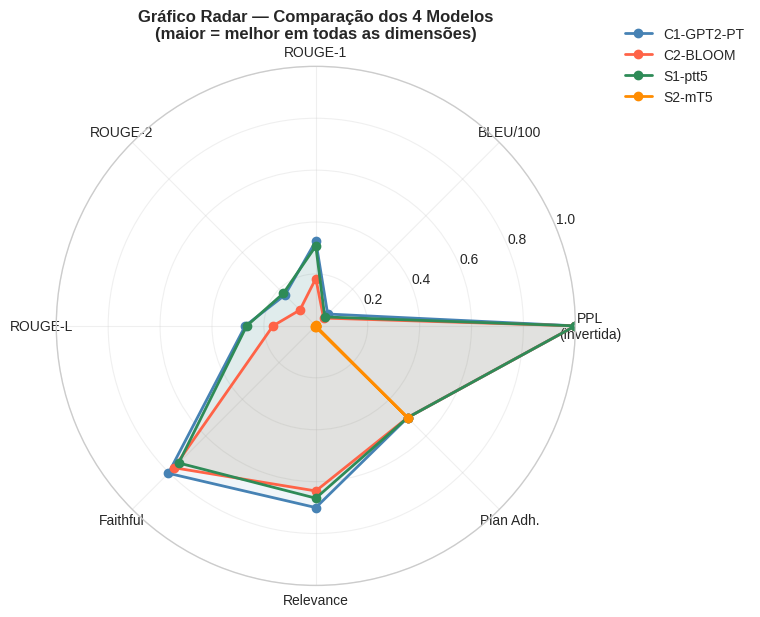

✅ Gráfico salvo em: /content/drive/MyDrive/radar_comparativo_4_modelos.png


In [ ]:
# Normaliza PPL para 0-1 invertido: ppl_norm = 1 - (ppl - ppl_min)/(ppl_max - ppl_min)
all_ppls = [np.mean(ppl_results[n]) for n in MODELS]
ppl_min, ppl_max = min(all_ppls), max(all_ppls)

def norm_ppl(ppl):
    if ppl_max == ppl_min:
        return 0.5
    return 1 - (ppl - ppl_min) / (ppl_max - ppl_min)


metric_labels = ['PPL\n(invertida)', 'BLEU/100', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L',
                 'Faithful', 'Relevance', 'Plan Adh.']

colors_radar = ['steelblue', 'tomato', 'seagreen', 'darkorange']
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

angles = np.linspace(0, 2 * np.pi, len(metric_labels), endpoint=False).tolist()
angles_closed = angles + [angles[0]]

for (name, _), color in zip(MODELS.items(), colors_radar):
    df_r = rouge_results[name]
    values = [
        norm_ppl(np.mean(ppl_results[name])),
        bleu_results[name]['corpus'] / 100,
        df_r['R1-F1'].mean(),
        df_r['R2-F1'].mean(),
        df_r['RL-F1'].mean(),
        np.mean(faith_results[name]),
        np.mean(relevance_results[name]),
        np.mean(plan_results[name]),
    ]
    values_closed = values + [values[0]]
    ax.plot(angles_closed, values_closed, 'o-', linewidth=2, color=color, label=name)
    ax.fill(angles_closed, values_closed, alpha=0.08, color=color)

ax.set_xticks(angles)
ax.set_xticklabels(metric_labels, size=10)
ax.set_ylim(0, 1)
ax.set_title('Gráfico Radar — Comparação dos 4 Modelos\n(maior = melhor em todas as dimensões)',
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/radar_comparativo_4_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo em: /content/drive/MyDrive/radar_comparativo_4_modelos.png')


## 🔬 16. Análise Qualitativa — 3 Amostras Lado a Lado

Selecionamos 3 amostras do conjunto de teste e exibimos, lado a lado,
as respostas geradas pelos 4 modelos e a resposta de referência.
Discutir o ganho de especialização no domínio.


In [ ]:
INSPECT_INDICES = [0, 4, 8]   # Ajuste para ver outras amostras

for idx in INSPECT_INDICES:
    s = samples[idx]
    print('=' * 70)
    print(f'AMOSTRA {idx + 1}')
    print(f'Instrução: {s["Instruction"]}')
    print()
    print(f'[REFERÊNCIA]:')
    print(f'  {s["Output"]}')
    print()
    for name in MODELS:
        gen  = all_generated[name][idx]
        r1   = rouge_results[name]['R1-F1'].iloc[idx]
        rL   = rouge_results[name]['RL-F1'].iloc[idx]
        faith = faith_results[name][idx]
        print(f'[{name}]:')
        print(f'  {gen if gen else "[sem saída]"}' )
        print(f'  ROUGE-1={r1:.3f}  ROUGE-L={rL:.3f}  Faithful={faith:.3f}')
        print()
    print()


AMOSTRA 1
Instrução: Qual é a principal função do manual de instruções fornecido pela Marchesan S.A.?

[REFERÊNCIA]:
  O manual de instruções serve para orientar sobre como usar efetivamente o equipamento, incluindo suas funções, procedimentos de operação e manutenção, além de garantir uma vida útil e confiabilidade máxima.

[C1-GPT2-PT]:
  A principal função do manual de instruções fornecido pela Marchesan S.A. é fornecer instruções específicas para a operação manual de instruções.
  ROUGE-1=0.349  ROUGE-L=0.286  Faithful=1.000

[C2-BLOOM]:
  O manual de instruções fornecido pela Marchesan S.A. é
  ROUGE-1=0.217  ROUGE-L=0.217  Faithful=0.667

[S1-ptt5]:
  O manual de instruções é fornecido pela Marchesan S.A..
  ROUGE-1=0.217  ROUGE-L=0.217  Faithful=0.667

[S2-mT5]:
  <extra_id_0>.
  ROUGE-1=0.000  ROUGE-L=0.000  Faithful=0.000


AMOSTRA 5
Instrução: Onde é necessário lubrificar o equipamento?

[REFERÊNCIA]:
  O equipamento deve ser lubrificado regularmente após cada lavagem.

[C1-G

## 📝 17. Relatório Final e Identificação do Melhor Modelo

Geração automática do relatório com identificação do melhor modelo.


In [ ]:
def interpret(value, metric_type):
    if metric_type == 'bleu':
        return '🟢 Bom' if value >= 30 else ('🟡 Moderado' if value >= 15 else '🔴 Fraco')
    elif metric_type == 'rouge':
        return '🟢 Bom' if value >= 0.5 else ('🟡 Moderado' if value >= 0.3 else '🔴 Fraco')
    else:
        return '🟢 Bom' if value >= 0.7 else ('🟡 Moderado' if value >= 0.4 else '🔴 Fraco')


print('=' * 70)
print('   RELATÓRIO DE AVALIAÇÃO — COMPARAÇÃO DOS 4 MODELOS')
print('   Grade Hidráulica GH — Marchesan (Manual Técnico)')
print('=' * 70)
print(f'   Amostras avaliadas : {len(samples)}')
print(f'   Dataset            : {DATASET_PATH}')
print(f'   Dispositivo        : {DEVICE}')
print()

for name in MODELS:
    df_r = rouge_results[name]
    ppl  = np.mean(ppl_results[name])
    bl   = bleu_results[name]['corpus']
    r1   = df_r['R1-F1'].mean()
    r2   = df_r['R2-F1'].mean()
    rL   = df_r['RL-F1'].mean()
    fa   = np.mean(faith_results[name])
    re   = np.mean(relevance_results[name])
    pl   = np.mean(plan_results[name])
    print(f'  ── {name} ──')
    print(f'    PPL             : {ppl:.2f}')
    print(f'    BLEU            : {bl:.2f}   {interpret(bl, "bleu")}')
    print(f'    ROUGE-1 F1      : {r1:.3f}  {interpret(r1, "rouge")}')
    print(f'    ROUGE-2 F1      : {r2:.3f}  {interpret(r2, "rouge")}')
    print(f'    ROUGE-L F1      : {rL:.3f}  {interpret(rL, "rouge")}')
    print(f'    Faithfulness    : {fa:.3f}  {interpret(fa, "other")}')
    print(f'    Ans. Relevance  : {re:.3f}  {interpret(re, "other")}')
    print(f'    Plan Adherence  : {pl:.3f}  {interpret(pl, "other")}')
    print()

# Identifica melhor modelo por ROUGE-L F1 (métrica mais equilibrada)
best_model = max(MODELS.keys(),
                 key=lambda n: rouge_results[n]['RL-F1'].mean())
print('─' * 70)
print(f'  🏆 MELHOR MODELO (por ROUGE-L F1): {best_model}')
print(f'     Justificativa: ROUGE-L captura ordem e estrutura textual,')
print(f'     sendo a métrica mais equilibrada para respostas técnicas curtas.')
print('=' * 70)


   RELATÓRIO DE AVALIAÇÃO — COMPARAÇÃO DOS 4 MODELOS
   Grade Hidráulica GH — Marchesan (Manual Técnico)
   Amostras avaliadas : 30
   Dataset            : /content/drive/MyDrive/dataset_gerado_v3 (1).jsonl
   Dispositivo        : cpu

  ── C1-GPT2-PT ──
    PPL             : 25.27
    BLEU            : 6.47   🔴 Fraco
    ROUGE-1 F1      : 0.327  🟡 Moderado
    ROUGE-2 F1      : 0.168  🔴 Fraco
    ROUGE-L F1      : 0.272  🔴 Fraco
    Faithfulness    : 0.803  🟢 Bom
    Ans. Relevance  : 0.700  🟢 Bom
    Plan Adherence  : 0.500  🟡 Moderado

  ── C2-BLOOM ──
    PPL             : 27.79
    BLEU            : 4.25   🔴 Fraco
    ROUGE-1 F1      : 0.183  🔴 Fraco
    ROUGE-2 F1      : 0.087  🔴 Fraco
    ROUGE-L F1      : 0.165  🔴 Fraco
    Faithfulness    : 0.773  🟢 Bom
    Ans. Relevance  : 0.636  🟡 Moderado
    Plan Adherence  : 0.500  🟡 Moderado

  ── S1-ptt5 ──
    PPL             : 26.99
    BLEU            : 4.87   🔴 Fraco
    ROUGE-1 F1      : 0.308  🟡 Moderado
    ROUGE-2 F1      : 0.1

## 💾 18. Exportar Resultados


In [ ]:
rows_export = []
for idx, s in enumerate(samples):
    row = {'Instrução': s['Instruction'], 'Referência': s['Output']}
    for name in MODELS:
        df_r = rouge_results[name]
        row[f'{name}_gerado']     = all_generated[name][idx]
        row[f'{name}_PPL']        = round(ppl_results[name][idx], 2)
        row[f'{name}_BLEU']       = round(bleu_results[name]['per_sample'][idx], 2)
        row[f'{name}_R1F1']       = round(df_r['R1-F1'].iloc[idx], 3)
        row[f'{name}_RLF1']       = round(df_r['RL-F1'].iloc[idx], 3)
        row[f'{name}_Faith']      = round(faith_results[name][idx], 3)
        row[f'{name}_Relevance']  = round(relevance_results[name][idx], 3)
        row[f'{name}_PlanAdh']    = round(plan_results[name][idx], 3)
    rows_export.append(row)

df_export = pd.DataFrame(rows_export)
CSV_PATH = '/content/drive/MyDrive/resultados_avaliacao_4_modelos.csv'
df_export.to_csv(CSV_PATH, index=False, encoding='utf-8-sig')

# Salva tabela comparativa de médias
SUMMARY_PATH = '/content/drive/MyDrive/tabela_comparativa_medias.csv'
df_comp.to_csv(SUMMARY_PATH, encoding='utf-8-sig')

print(f'✅ Exportado:')
print(f'   {CSV_PATH}')
print(f'   {SUMMARY_PATH}')
print(f'   /content/drive/MyDrive/radar_comparativo_4_modelos.png')
print()
print('🎉 Avaliação concluída! Todos os artefatos da Etapa 3 foram gerados.')


✅ Exportado:
   /content/drive/MyDrive/resultados_avaliacao_4_modelos.csv
   /content/drive/MyDrive/tabela_comparativa_medias.csv
   /content/drive/MyDrive/radar_comparativo_4_modelos.png

🎉 Avaliação concluída! Todos os artefatos da Etapa 3 foram gerados.
